In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
df = pd.read_csv('house_prices_train.csv.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 📍 Genel Özellikler & Konum
* **Id:** Her bir evin benzersiz kimlik numarası.
* **MSSubClass:** Satışa konu olan konutun yapısını/tipini belirten kod (ör. 2 katlı, prefabrik vb.).
* **MSZoning:** Genel imar/bölge sınıflandırması (Konut, Ticari, Ziraat vb.).
* **LotFrontage:** Evin caddeye/sokağa olan doğrusal cephe mesafesi (feet).
* **LotArea:** Parsel/Arsa alanı (square feet).
* **Street:** Parsel erişiminin sağlandığı yol tipi (Asfalt / Çakıl).
* **Alley:** Arka hat/söz konusu ara sokak erişim tipi.
* **LotShape:** Mülkün genel şekli (Düzgün, Düzensiz vb.).
* **LandContour:** Evin kurulduğu arazinin düzlük/eğim durumu.
* **Utilities:** Mevcut altyapı hizmetleri (Elektrik, Gaz, Su, Kanalizasyon).
* **LotConfig:** Parsel yapılandırması (Köşe parsel, İç parsel vb.).
* **LandSlope:** Arazinin eğim derecesi.
* **Neighborhood:** Evin Ames şehri sınırları içerisindeki fiziksel mahallesi/konumu.
* **Condition1:** Çeşitli ulaşım veya ana yollara/demiryollarına yakınlık durumu.
* **Condition2:** İkinci bir ulaşım/demiryolu yakınlığı varsa bunun durumu.

### 🏗️ Bina Tipi, Yaş & Mimari
* **BldgType:** Konutun tipi (Müstakil, İkiz Ev, Townhouse vb.).
* **HouseStyle:** Konutun mimari tarzı (Tek katlı, 2 katlı, Yarım katlı vb.).
* **OverallQual:** Malzeme ve bitiriş kalitesi (1: Çok Kötü - 10: Mükemmel).
* **OverallCond:** Evin genel durum değerlendirmesi (1: Çok Kötü - 10: Mükemmel).
* **YearBuilt:** Orijinal yapım yılı.
* **YearRemodAdd:** Tadilat/Yenilenme tarihi (Hiç yapılmadıysa yapım yılı ile aynıdır).
* **RoofStyle:** Çatı tipi (Kırma çatı, Beşik çatı vb.).
* **RoofMatl:** Çatı malzemesi (Kiremit, Ahşap, Membran vb.).
* **Exterior1st:** Evin dış kaplaması (Birincil malzeme).
* **Exterior2nd:** Evin dış kaplaması (İkinci bir malzeme varsa).
* **MasVnrType:** Tuğla/Taş kaplama türü.
* **MasVnrArea:** Tuğla/Taş kaplama alanı (square feet).
* **ExterQual:** Dış cephe malzemesinin kalitesi.
* **ExterCond:** Dış cephe malzemesinin mevcut durumu.

### 🧱 Temel (Bodrum / Foundation) Özellikleri
* **Foundation:** Temel tipi (Beton, Tuğla, Blok vb.).
* **BsmtQual:** Bodrum yüksekliği ve kalitesi değerlendirmesi.
* **BsmtCond:** Bodrumun genel durumu.
* **BsmtExposure:** Bodrumun yürüyüş düzeyi veya çıkış duvarları (Işık alma durumu).
* **BsmtFinType1:** Tamamlanmış bodrum alanının kalitesi/tipi.
* **BsmtFinSF1:** Tipi belirlenmiş 1. bitmiş bodrum alanı (sq ft).
* **BsmtFinType2:** İkinci bir bitmiş bodrum alanı varsa onun kalitesi.
* **BsmtFinSF2:** İkinci bitmiş bodrum alanı (sq ft).
* **BsmtUnfSF:** Bitmemiş/Ham bodrum alanı (sq ft).
* **TotalBsmtSF:** Toplam bodrum alanı (sq ft).

### 🛋️ Isıtma, Soğutma & Yaşam Alanı
* **Heating:** Isıtma tipi (Gaz, Buhar, Radyatör vb.).
* **HeatingQC:** Isıtma kalitesi ve durumu.
* **CentralAir:** Merkezi klima var mı (Y: Evet, N: Hayır).
* **Electrical:** Elektrik sistemi türü.
* **1stFlrSF:** 1. Kat yaşam alanı (sq ft).
* **2ndFlrSF:** 2. Kat yaşam alanı (sq ft).
* **LowQualFinSF:** Düşük kaliteli bitirilmiş alan (Tüm katlarda).
* **GrLivArea:** Zemin üstü (toplam) yaşam alanı (sq ft).
* **BsmtFullBath:** Bodrumdaki tam banyo sayısı.
* **BsmtHalfBath:** Bodrumdaki yarım banyo sayısı.
* **FullBath:** Zemin üstündeki tam banyo sayısı.
* **HalfBath:** Zemin üstündeki yarım banyo sayısı.
* **BedroomAbvGr:** Zemin üstündeki yatak odası sayısı (Bodrum hariç).
* **KitchenAbvGr:** Zemin üstündeki mutfak sayısı.
* **KitchenQual:** Mutfak kalitesi.
* **TotRmsAbvGrd:** Zemin üstündeki toplam oda sayısı (Banyolar hariç).
* **Functional:** Evin işlevsellik derecesi (Hasar/Kusur durumu).
* **Fireplaces:** Şömine sayısı.
* **FireplaceQu:** Şömine kalitesi.

### 🚗 Garaj Özellikleri
* **GarageType:** Garajın yeri ve tipi (Müstakil, Eklenti vb.).
* **GarageYrBlt:** Garajın inşa edildiği yıl.
* **GarageFinish:** Garajın iç bitiş durumu (Ham, Sıvalı, Bitmiş).
* **GarageCars:** Garajın araç kapasitesi.
* **GarageArea:** Garaj alanı (sq ft).
* **GarageQual:** Garaj kalitesi.
* **GarageCond:** Garaj durumu.
* **PavedDrive:** Garaj yolunun kaplama durumu (Asfalt/Beton, Çakıl).

### 🏊 Açık Alanlar, Havuz & Satış Detayları
* **WoodDeckSF:** Ahşap güverte/teras alanı (sq ft).
* **OpenPorchSF:** Açık sundurma/veranda alanı (sq ft).
* **EnclosedPorch:** Kapalı veranda alanı (sq ft).
* **3SsnPorch:** 3 Mevsim sundurma alanı (sq ft).
* **ScreenPorch:** Sineklikli/Camlı veranda alanı (sq ft).
* **PoolArea:** Havuz alanı (sq ft).
* **PoolQC:** Havuz kalitesi.
* **Fence:** Çit kalitesi/tipi.
* **MiscFeature:** Diğer kategorilere girmeyen ekstra özellikler (Asansör, İkinci Garaj vb.).
* **MiscVal:** Ekstra özelliğin değeri ($).
* **MoSold:** Satıldığı ay (1-12).
* **YrSold:** Satıldığı yıl.
* **SaleType:** Satış türü (Taksitli, Peşin, Yeni İnşaat vb.).
* **SaleCondition:** Satış koşulu (Normal, Bankadan, Aile İçi vb.).
* **SalePrice:** Evin satış fiyatı (**HEDEF DEĞİŞKENİMİZ** - $).

In [5]:
df['Street'].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [6]:
cols_drop = ['Alley','PoolQC','Fence','MiscFeature']

In [7]:
df = df.drop(columns=cols_drop)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [9]:
# cok fazla verisi eksik olanlari silmeyi tercih ettim 

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage     259
MasVnrType      872
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [11]:
# bazi katagorilerde bos veriler o seyin o evde olmadigini gostermek icin kullanilmistir bundan dolayi o bos verileri 0 ile doldurmayi tercih edicem 

In [12]:
# İçinde eksik değer (NaN) olan sayısal sütunların listesini dinamik olarak alır
num_zeros = df.select_dtypes(include=['int64', 'float64']).columns[df.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

print(num_zeros)

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']


In [13]:
# kategorik degiskleri dolduracam 

In [14]:
cat_cols_none = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'FireplaceQu', 'MasVnrType'
]

df[cat_cols_none] = df[cat_cols_none].fillna('None')

In [15]:
# sayisal kolonlarda bos olan verileri 0 ile dolduracam 

In [16]:
num_cols_zero = ['MasVnrArea', 'GarageYrBlt']

df[num_cols_zero] = df[num_cols_zero].fillna(0)

In [17]:
# electrical kolonou 1 tane bosluk var bundan dolayi en cok tekrar edeni koyucam

In [18]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [19]:
# lotfrontage kismini mahalleye gore median ile dolduracam 

In [20]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [21]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 77, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [23]:
# ONE HOT ENCODING 

ordinal_columns_info = {  
    
    
    # 1. Standart Kalite ve Durum Kolonları (Ex > Gd > TA > Fa > Po > None)
    'ExterQual': 'Dış cephe malzeme kalitesi (Ex, Gd, TA, Fa, Po)',
    'ExterCond': 'Dış cephe malzemenin mevcut durumu (Ex, Gd, TA, Fa, Po)',
    'BsmtQual': 'Bodrum yüksekliği ve genel kalitesi (Ex, Gd, TA, Fa, Po, None)',
    'BsmtCond': 'Bodrumun genel durumu (Ex, Gd, TA, Fa, Po, None)',
    'HeatingQC': 'Isıtma kalitesi ve durumu (Ex, Gd, TA, Fa, Po)',
    'KitchenQual': 'Mutfak kalitesi (Ex, Gd, TA, Fa, Po)',
    'FireplaceQu': 'Şömine kalitesi (Ex, Gd, TA, Fa, Po, None)',
    'GarageQual': 'Garaj kalitesi (Ex, Gd, TA, Fa, Po, None)',
    'GarageCond': 'Garaj durumu (Ex, Gd, TA, Fa, Po, None)',

    # 2. Bodrum ve Garaj Detay Kolonları
    'BsmtFinType1': '1. Bodrum alanının bitmişlik kalitesi (GLQ, ALQ, BLQ, Rec, LwQ, Unf, None)',
    'BsmtFinType2': '2. Bodrum alanının bitmişlik kalitesi (GLQ, ALQ, BLQ, Rec, LwQ, Unf, None)',
    'BsmtExposure': 'Bodrumun gün ışığı / dışarı açılma seviyesi (Gd, Av, Mn, No, None)',
    'GarageFinish': 'Garajın iç bitmişlik durumu (Fin, RFn, Unf, None)',

    # 3. Diğer Yapısal Derece Kolonları
    'Functional': 'Evin genel kullanım fonksiyonelliği (Typ, Min1, Min2, Mod, Maj1, Maj2, Sev, Sal)',
    'LandSlope': 'Arsanın eğim durumu (Gtl, Mod, Sev)',
    'PavedDrive': 'Garaj/Araç yolu kaplama durumu (Y, P, N)',
    'Utilities': 'Evdeki altyapı/imkan seviyesi (AllPub, NoSewr, NoSeWa, ELO)'
}

In [24]:
# yukarida kismi yapay zekaya yaptirdim bu tabloya bakarak kolayca kodlamami yapicam

In [25]:
df['ExterQual'].value_counts()

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

In [26]:
Ex_qual = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1}
df['ExterQual'] = df['ExterQual'].map(Ex_qual)

In [27]:
df['ExterQual'].value_counts()

ExterQual
3    906
4    488
5     52
2     14
Name: count, dtype: int64

In [28]:
Ex_con = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1}
df['ExterCond'] = df['ExterCond'].map(Ex_con)

In [29]:
df['ExterCond'].value_counts()

ExterCond
3    1282
4     146
2      28
5       3
1       1
Name: count, dtype: int64

In [30]:
Bsm_qual = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['BsmtQual'] = df['BsmtQual'].map(Bsm_qual)

In [31]:
df['BsmtQual'].value_counts()

BsmtQual
3    649
4    618
5    121
0     37
2     35
Name: count, dtype: int64

In [32]:
Bsm_con = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['BsmtCond'] = df['BsmtCond'].map(Bsm_con)

In [33]:
df['BsmtCond'].value_counts()

BsmtCond
3    1311
4      65
2      45
0      37
1       2
Name: count, dtype: int64

In [34]:
Heat_QC = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['HeatingQC'] = df['HeatingQC'].map(Heat_QC)

In [35]:
df['HeatingQC'].value_counts()

HeatingQC
5    741
3    428
4    241
2     49
1      1
Name: count, dtype: int64

In [36]:
Kit_Qual = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['KitchenQual'] = df['KitchenQual'].map(Kit_Qual)

In [37]:
df['KitchenQual'].value_counts()

KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64

In [38]:
Fire_Qu = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['FireplaceQu'] = df['FireplaceQu'].map(Fire_Qu)

In [39]:
df['FireplaceQu'].value_counts()

FireplaceQu
0    690
4    380
3    313
2     33
5     24
1     20
Name: count, dtype: int64

In [40]:
Gara_Qual = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['GarageQual'] = df['GarageQual'].map(Gara_Qual)

In [41]:
df['GarageQual'].value_counts()

GarageQual
3    1311
0      81
2      48
4      14
5       3
1       3
Name: count, dtype: int64

In [42]:
Gara_cond = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
df['GarageCond'] = df['GarageCond'].map(Gara_cond)

In [43]:
df['GarageCond'].value_counts()

GarageCond
3    1326
0      81
2      35
4       9
1       7
5       2
Name: count, dtype: int64

In [44]:
Bsmt_1 = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
df['BsmtFinType1'] = df['BsmtFinType1'].map(Bsmt_1).astype(int)

In [45]:
df['BsmtFinType1'].value_counts()

BsmtFinType1
1    430
6    418
5    220
4    148
3    133
2     74
0     37
Name: count, dtype: int64

In [46]:
Bsmt_2 = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
df['BsmtFinType2'] = df['BsmtFinType2'].map(Bsmt_2).astype(int)

In [47]:
df['BsmtFinType2'].value_counts()

BsmtFinType2
1    1256
3      54
2      46
0      38
4      33
5      19
6      14
Name: count, dtype: int64

In [48]:
bsmt_Ex = {'Gd': 4,'Av': 3,'Mn': 2,'No': 1,'None': 0 } 
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_Ex)

In [49]:
df['BsmtExposure'].value_counts()

BsmtExposure
1    953
3    221
4    134
2    114
0     38
Name: count, dtype: int64

In [50]:
Gara_Fi = {'Fin':4,'RFn':3,'Unf':2,'None':1} 
df['GarageFinish'] = df['GarageFinish'].map(Gara_Fi).astype(int)

In [51]:
df['GarageFinish'].value_counts()

GarageFinish
2    605
3    422
4    352
1     81
Name: count, dtype: int64

In [52]:
func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
df['Functional'] = df['Functional'].map(func_map).astype(int)

In [53]:
df['Functional'].value_counts()

Functional
7    1360
5      34
6      31
4      15
3      14
2       5
1       1
Name: count, dtype: int64

In [54]:
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
df['LandSlope'] = df['LandSlope'].map(slope_map).astype(int)

In [55]:
df['LandSlope'].value_counts()

LandSlope
3    1382
2      65
1      13
Name: count, dtype: int64

In [56]:
paved_map = {'Y': 2, 'P': 1, 'N': 0}
df['PavedDrive'] = df['PavedDrive'].map(paved_map).astype(int)

In [57]:
df['PavedDrive'].value_counts()

PavedDrive
2    1340
0      90
1      30
Name: count, dtype: int64

In [58]:
util_map = {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}
df['Utilities'] = df['Utilities'].map(util_map).astype(int)

In [59]:
df['Utilities'].value_counts()

Utilities
3    1459
1       1
Name: count, dtype: int64

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [61]:
# Tüm object (metin) kolonlarını bulup One-Hot Encoding uygular
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 198 entries, Id to SaleCondition_Partial
dtypes: float64(3), int64(195)
memory usage: 2.2 MB


In [63]:
 # EDA 

C:\Users\PC\AppData\Local\Temp\ipykernel_20036\3592430128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='OverallQual',y='SalePrice',palette='viridis')


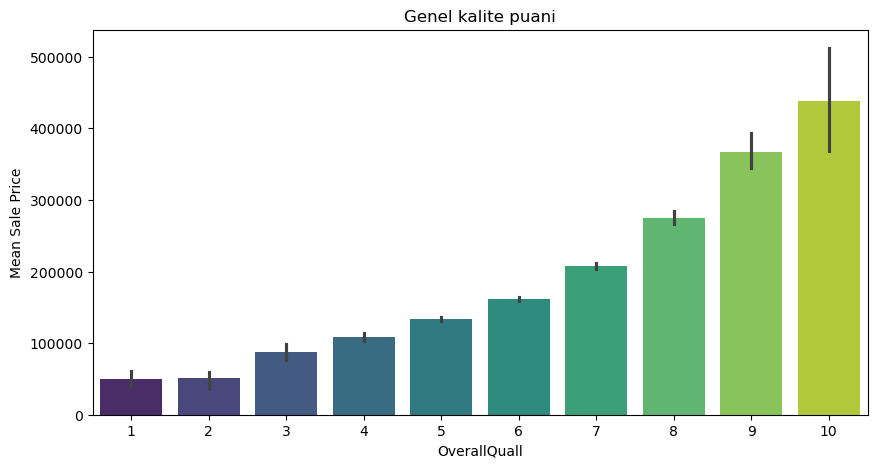

In [64]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='OverallQual',y='SalePrice',palette='viridis')
plt.title('Genel kalite puani')
plt.xlabel('OverallQuall')
plt.ylabel('Mean Sale Price')
plt.show()

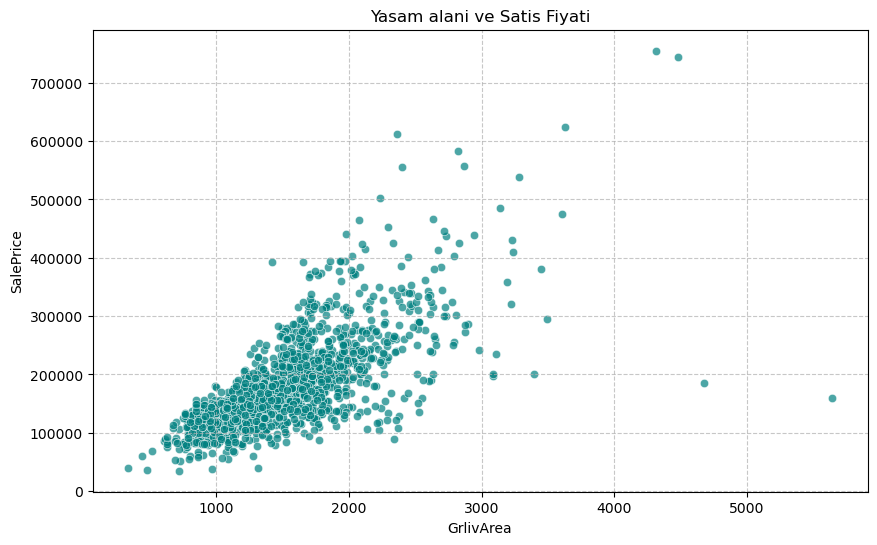

In [65]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice',color='teal',alpha=0.7)
plt.title('Yasam alani ve Satis Fiyati')
plt.xlabel('GrlivArea')
plt.ylabel('SalePrice')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

 Amerikada bir evde fiyati en cok etkileyecek sey fitkaredir (fitkare, metrekareden biraz daha kucuktur) yani evin boyutu fiyati
en cok etkileyen faktorlerden oldugu icin ve buna ait aykiri degerleri gormek icin scatterplot cizdirmeyi uygun gordu 
scatterplot bize 2 sayisal veri arasindaki dogrusal ilskiyi aciklmada yardimci oluyor

in the US the factor that affects the price of a house the most is square footage(square feet are slightly smaller than square meters)  since house
size is the main factor influencing price i chose to plot a scatter plot to abserve its outliers scatter plots help us explain the linear relationship 
between two numerical variables 

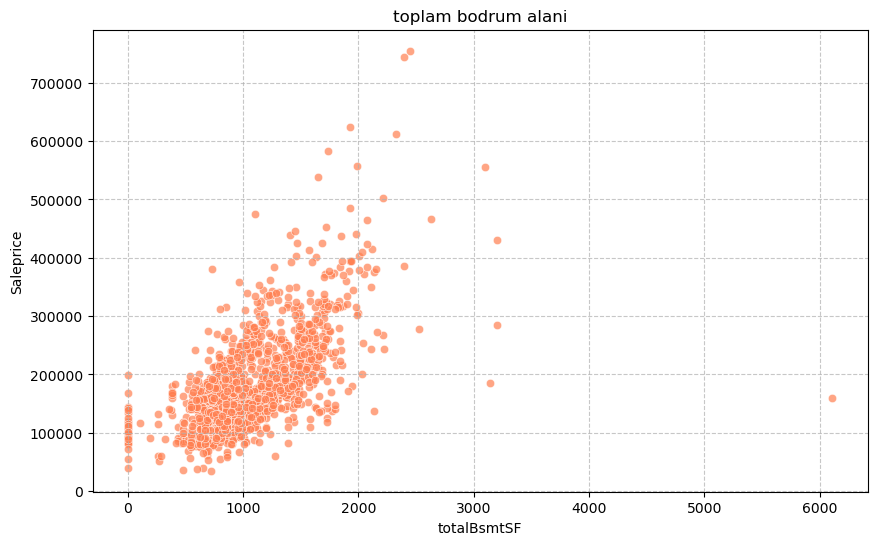

In [66]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='TotalBsmtSF',y='SalePrice',color='coral',alpha=0.7)
plt.title('toplam bodrum alani')
plt.xlabel('totalBsmtSF')
plt.ylabel('Saleprice')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

evdeki bodrum faktorude amerikada fiyati cok etkiler bundan dolayi ev fiyati ile bodrum arasindaki ilskiyi gormek icin scatterplot kullandim 

the basement factor in a house also significantly affects the price in the Us so i used a sacatter plot to see the relationship between house and
the basament

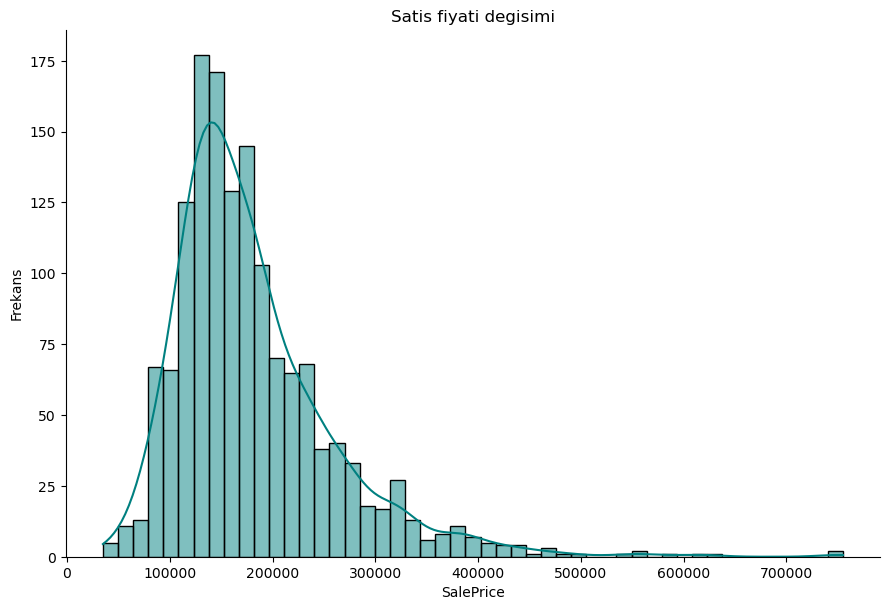

In [67]:
sns.displot(data=df,x='SalePrice',kde=True,aspect=1.5,height=6,color='teal')
plt.title('Satis fiyati degisimi')
plt.xlabel('SalePrice')
plt.ylabel('Frekans')
plt.show()

genelde amerikadaki orta kesime hitap eden evlerin daha cok satildigini goruyoruz 

we see that house catering to the middle class in the US are generally sold more often 

C:\Users\PC\AppData\Local\Temp\ipykernel_20036\3824312298.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df,x='OverallQual',y='SalePrice',kind='box',aspect=1.5,height=6,palette='viridis')


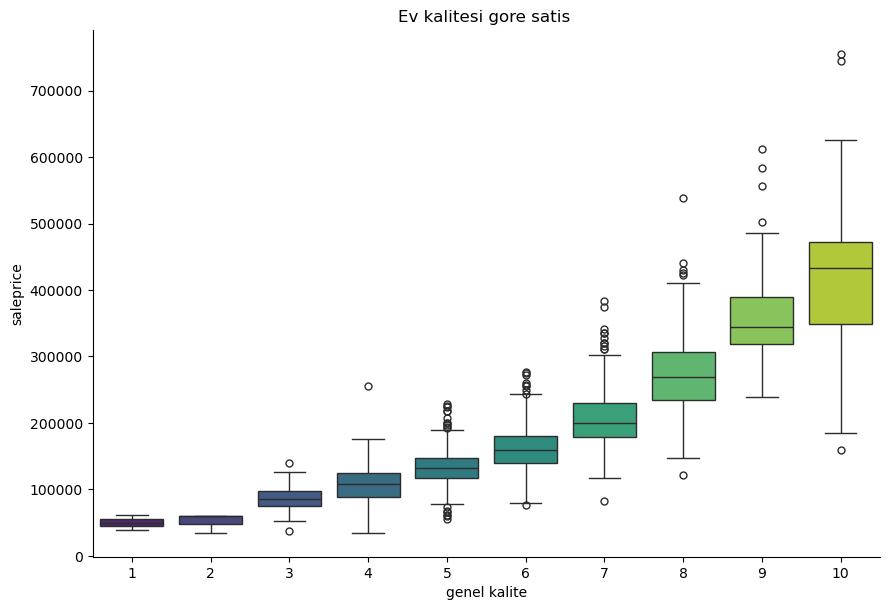

In [68]:
sns.catplot(data=df,x='OverallQual',y='SalePrice',kind='box',aspect=1.5,height=6,palette='viridis')
plt.title('Ev kalitesi gore satis ')
plt.xlabel('genel kalite')
plt.ylabel('saleprice')
plt.show()

ev fiyati arttiginda kalitenin artmasi zaten cok beklenen bir durum ama kalitenin yuksek oldugu yerlede medyan cizgisinin yukari dogru yani daha
fazla paraya kaydigini ve kutularin genisligine bakildiginda kalite arttikca varyansinda arttigini gorebiliyoruzz ayri encok aykiri degerin 5 6 ve 7 kisimda oldugunu goruyoruz buda bize en cok vernin burada oldugunu soyluyor 

While an increase in price as quality improves is highly expected, we can see that at higher quality levels, the median line shifts upward toward higher price points. Looking at the box height (interquartile range), it is evident that price variance increases alongside quality. Additionally, we observe that outliers are most concentrated around quality levels 5, 6, and 7, which indicates that the bulk of the data is clustered in this mid-tier range

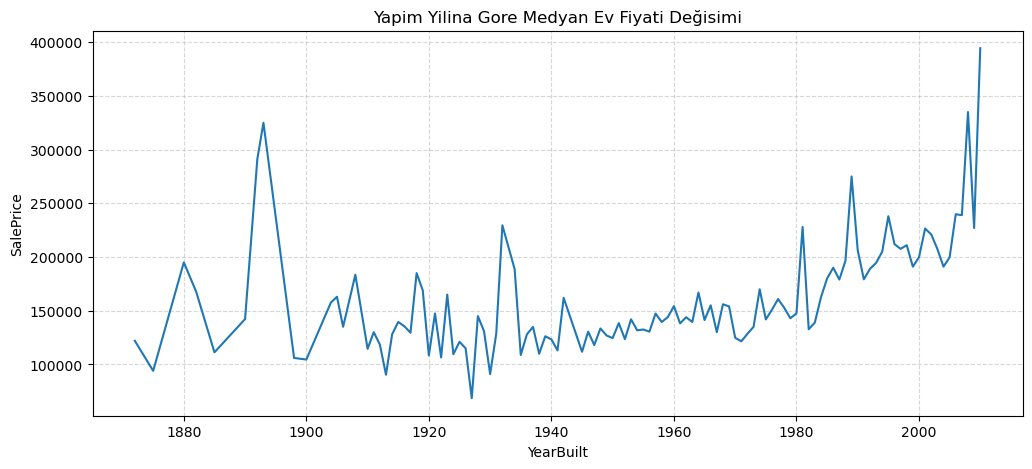

In [69]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='YearBuilt', y='SalePrice', estimator='median', errorbar=None)
plt.title('Yapim Yilina Gore Medyan Ev Fiyati Değisimi')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Grafiğe baktığımızda 1880-1900 yılları arasındaki keskin sıçrama ve düşüşler o yıllara ait veri sayısının az olmasından kaynaklanmaktadır. Genel trende baktığımızda ise 1900'lerden itibaren fiyatların zamanla kademeli olarak arttığı, özellikle 2000 sonrasında inşa edilen yeni evlerde medyan fiyatların çok daha yüksek seviyelere ulaştığı ve dalgalanmaların arttığı görülmektedir.

Looking at the plot, the sharp spikes between 1880 and 1900 are primarily due to a small sample size for those construction years. Overall, we observe a general upward trend in home prices starting from the 1900s, with median prices reaching significantly higher levels and showing increased volatility for houses built after 2000

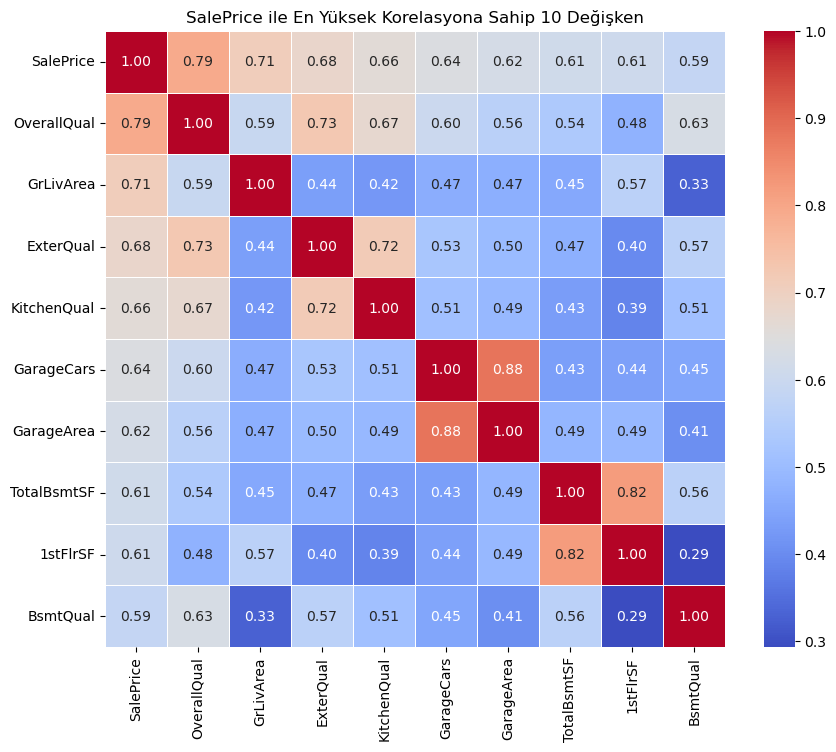

In [70]:
top_corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_corr].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('SalePrice ile En Yüksek Korelasyona Sahip 10 Değişken')
plt.show()


In [71]:
# Feature Engineering

In [72]:
X = df.drop('SalePrice',axis=1)
y = df['SalePrice']

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [75]:
X_train.corr()

,Id,MSSubClass,LotFrontage,LotArea,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,1.000000,-0.017778,-0.017644,-0.026320,NaN,0.015079,-0.062343,0.009626,-0.022645,-0.041192,...,-0.059374,-0.044756,-0.029208,0.047207,0.023127,-0.057521,-0.013574,-0.005087,0.014228,-0.031450
MSSubClass,-0.017778,1.000000,-0.363219,-0.215870,NaN,0.061757,0.067927,-0.060318,0.060419,0.081725,...,-0.017671,0.012252,-0.034454,-0.017671,0.028008,0.008430,0.025372,0.016220,0.027471,-0.043196
LotFrontage,-0.017644,-0.363219,1.000000,0.392946,NaN,-0.087982,0.229620,-0.046984,0.111029,0.064361,...,-0.007312,-0.063471,0.106747,-0.027613,-0.078980,-0.022147,-0.013488,0.010987,-0.071789,0.104423
LotArea,-0.026320,-0.215870,0.392946,1.000000,NaN,-0.387109,0.115750,-0.029636,0.012733,0.003682,...,-0.001036,-0.018716,0.021578,-0.007215,-0.002260,-0.017361,0.025591,-0.014084,-0.003454,0.025626
Utilities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleCondition_AdjLand,-0.057521,0.008430,-0.022147,-0.017361,NaN,0.012300,-0.056468,-0.043432,-0.066826,-0.046517,...,-0.002944,-0.003401,-0.016342,-0.002944,0.021168,1.000000,-0.004819,-0.007057,-0.114282,-0.016655
SaleCondition_Alloca,-0.013574,0.025372,-0.013488,0.025591,NaN,-0.060248,-0.030200,-0.034039,-0.015094,-0.033114,...,-0.004819,-0.005568,-0.026753,-0.004819,0.034652,-0.004819,1.000000,-0.011552,-0.187081,-0.027264
SaleCondition_Family,-0.005087,0.016220,0.010987,-0.014084,NaN,-0.053600,-0.042123,-0.029820,-0.037415,-0.042186,...,-0.007057,-0.008153,-0.039172,-0.007057,0.050740,-0.007057,-0.011552,1.000000,-0.273934,-0.039922
SaleCondition_Normal,0.014228,0.027471,-0.071789,-0.003454,NaN,0.038643,-0.118318,0.162408,-0.146151,-0.114697,...,0.025761,0.029761,-0.634372,-0.114282,0.627767,-0.114282,-0.187081,-0.273934,1.000000,-0.646505


In [76]:
def correlation_for_dropping(df, threshold):
    col_corr = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                col_corr.add(colname)
    return list(col_corr)

In [77]:
correlation_for_dropping(X_train,0.85)

['RoofStyle_Hip',
 'Exterior2nd_CmentBd',
 'Exterior2nd_VinylSd',
 'GarageCond',
 'Exterior2nd_CBlock',
 'Neighborhood_Somerst',
 'FireplaceQu',
 'GarageType_None',
 'Exterior2nd_HdBoard',
 'Exterior2nd_MetalSd',
 'Exterior2nd_Wd Sdng',
 'SaleCondition_Partial',
 'GarageQual',
 'GarageArea']

In [78]:
def correlation_for_dropping(df,threshold):# threshold örnegin 85 yukarısnı çıkart için kullanıyoruz
    corr = df.corr()
    columns_to_drop = set()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop            

    ## çok öneml bir def fonkisyonu 

In [79]:
# Yüksek korelasyonlu sütunları tespit et
drop_cols = correlation_for_dropping(X_train, 0.85)
print("Elenen Sütunlar:", drop_cols)

# Sütunları train ve test setinden düşür
X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

Elenen Sütunlar: {'RoofStyle_Hip', 'Exterior2nd_CmentBd', 'Exterior2nd_VinylSd', 'GarageCond', 'Exterior2nd_CBlock', 'Neighborhood_Somerst', 'FireplaceQu', 'GarageType_None', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_Wd Sdng', 'SaleCondition_Partial', 'GarageQual', 'GarageArea'}


In [80]:
from sklearn.preprocessing import StandardScaler

In [81]:
scaler = StandardScaler()

In [82]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
regression = LinearRegression()

In [85]:
regression.fit(X_train_scaler,y_train)

LinearRegression()

In [86]:
print("Coefficent:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficent: [ 1.52346407e+00 -1.84337452e+01  1.51852482e+02  3.46600247e-01
  1.62118024e-05 -6.59503119e+03  7.90063025e+03  5.87798691e+03
  3.12699495e+02  1.32693179e+01  2.64482590e+01  5.95985489e+03
 -4.08103125e+03  4.67282976e+03 -5.44497948e+03  4.28897204e+03
  2.52645665e+01  1.39580388e+01  6.63050286e+02  3.90711282e+00
 -3.58934444e+00  1.42760626e+01  3.56320296e+02  3.13650856e+01
  4.04398267e+01 -4.42876350e+01  2.75172296e+01  2.44949985e+03
 -1.62008453e+03 -8.70846498e+02 -5.59325451e+02 -5.34138425e+03
 -6.34572097e+03  5.58956564e+03  1.62118725e+03  6.44065652e+03
  1.49833239e+03 -1.39370466e+01  2.69223499e+03  6.94414477e+03
 -1.59915439e+03  1.12613318e+01  3.88607994e+00 -8.14930296e+00
  4.83451465e+01  3.62220650e+01  7.45850518e+01 -9.09463281e-01
 -7.68611276e+02  6.75214008e+02  3.73173522e+04  4.06941785e+04
  3.73895218e+04  3.41714178e+04  7.62953741e+03  6.79151944e+03
  7.65573254e+03  2.37507628e+03  4.94726377e+02 -7.51607095e+03
  5.87389974e

In [87]:
y_pred = regression.predict(X_test)

In [88]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [89]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2_score',score)

mae 20511.834379451648
mse 1771114508.8812103
r2_score 0.7533702968242735


In [90]:
from sklearn.preprocessing import PolynomialFeatures

In [91]:
poly = PolynomialFeatures(degree=2,include_bias=False)

In [92]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [93]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [94]:
y_pred_poly = regression.predict(X_test_poly)
r2_score(y_test,y_pred_poly)

-13.481876807517363

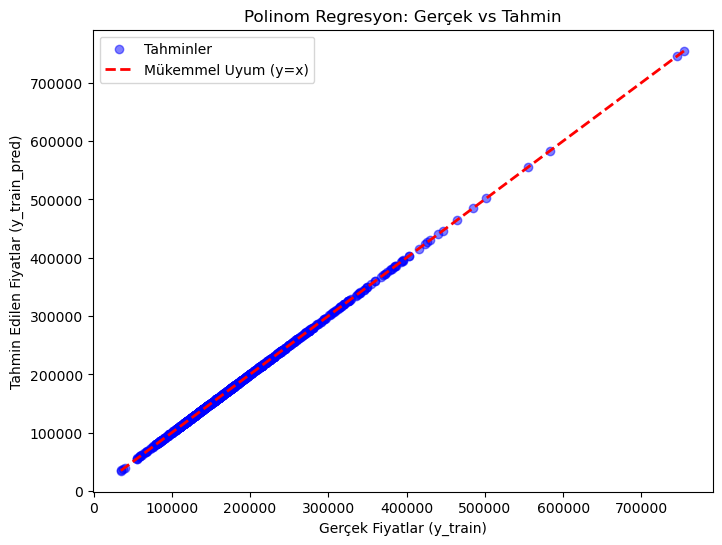

In [95]:
y_train_pred = regression.predict(X_train_poly)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label='Tahminler')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Mükemmel Uyum (y=x)')
plt.xlabel('Gerçek Fiyatlar (y_train)')
plt.ylabel('Tahmin Edilen Fiyatlar (y_train_pred)')
plt.title('Polinom Regresyon: Gerçek vs Tahmin')
plt.legend()
plt.show()

In [96]:
# MULTICOLLINERATIY 

In [97]:
# LINEARREGRESSION MODEL

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae 20511.834379438933
mse 1771114508.8667336
r2 score 0.7533702968262894


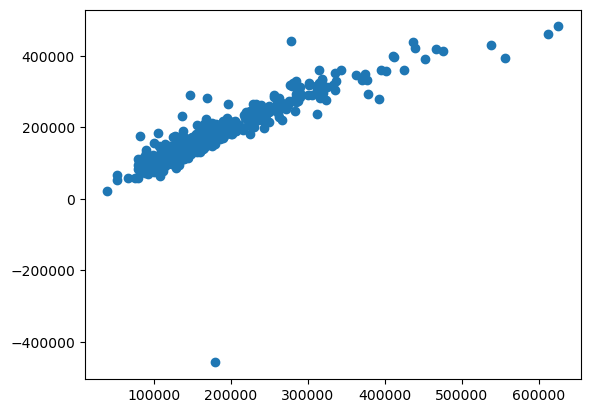

In [99]:
linear = LinearRegression()
linear.fit(X_train_scaler,y_train)
y_pred = linear.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

LASSO

In [100]:
from sklearn.linear_model import Lasso

mae 20493.09437037648
mse 1767225464.7504096
r2 score 0.7539118506282806


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.267e+09, tolerance: 6.059e+08
  model = cd_fast.enet_coordinate_descent(


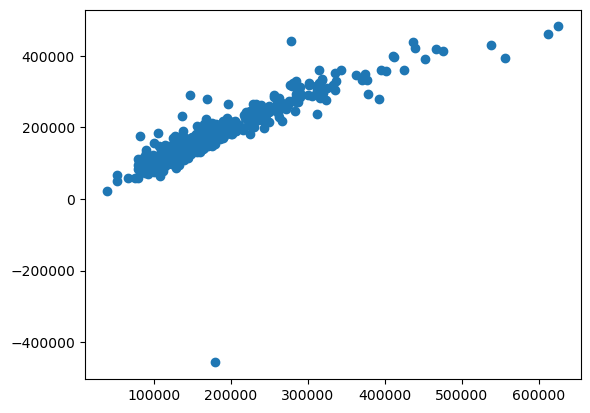

In [101]:
lasso = Lasso()
lasso.fit(X_train_scaler,y_train)
y_pred = lasso.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

RIDGE

In [102]:
from sklearn.linear_model import Ridge

mae 20343.678639586014
mse 1620932070.833084
r2 score 0.7742833715759527


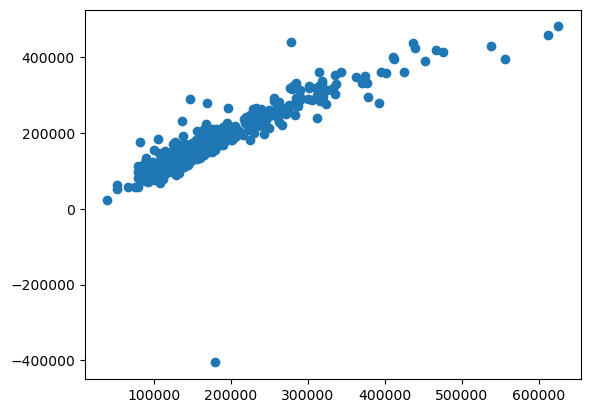

In [103]:
ridge = Ridge()
ridge.fit(X_train_scaler,y_train)
y_pred = ridge.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

ELASTICNET

In [104]:
from sklearn.linear_model import ElasticNet

mae 18919.896971980234
mse 942102806.3902869
r2 score 0.8688111162005961


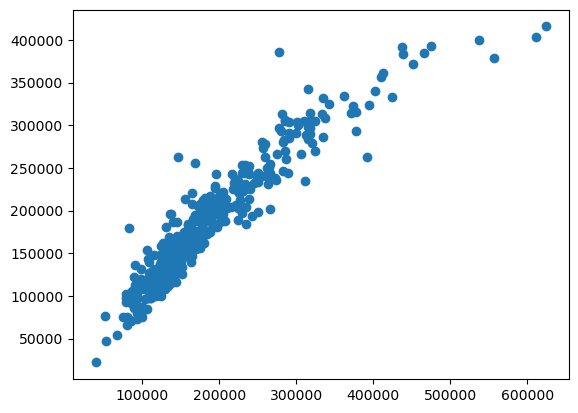

In [105]:
elastic = ElasticNet()
elastic.fit(X_train_scaler,y_train)
y_pred = elastic.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

LASSOCV

In [106]:
from sklearn.linear_model import LassoCV

mae 22134.640716844544
mse 1299413648.7218847
r2 score 0.819055176342491


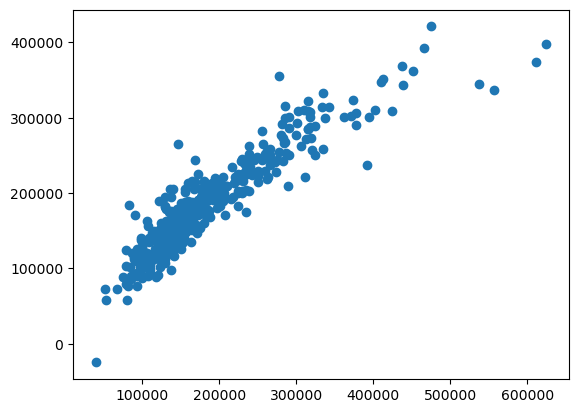

In [107]:
lassocv = LassoCV()
lassocv.fit(X_train_scaler,y_train)
y_pred = lassocv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

RIDGECV

In [108]:
from sklearn.linear_model import RidgeCV

mae 19684.777632213027
mse 1097578009.557813
r2 score 0.847161017905927


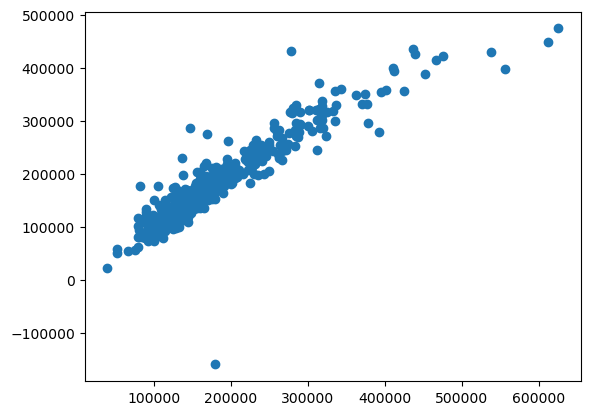

In [109]:
ridgecv = RidgeCV()
ridgecv.fit(X_train_scaler,y_train)
y_pred = ridgecv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

ELASTICNETCV

In [110]:
from sklearn.linear_model  import ElasticNetCV

mae 52416.438188809036
mse 5593591416.2475
r2 score 0.22108605414403526


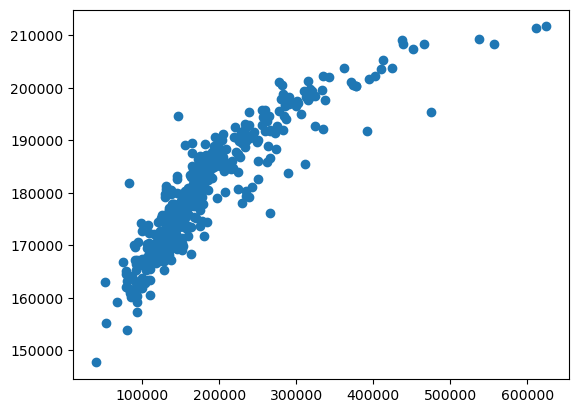

In [111]:
elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaler,y_train)
y_pred = elasticnetcv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()


ElasticNetCV varsayılan parametrelerde katsayıları aşırı baskılayıp modeli çökerttiği için; geniş bir $\alpha$ ve $l1\_ratio$ aralığı vererek veriye en uygun ceza katsayısını çapraz doğrulamayla otomatize ettik

mae 19619.034847437553
mse 1056467603.9393984
r2 score 0.8528856884928717


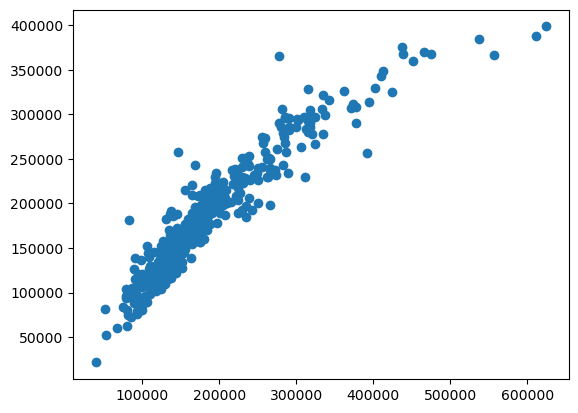

In [112]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

elasticnetcv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    cv=5,
    max_iter=50000
)

elasticnetcv.fit(X_train_scaler, y_train)
y_pred = elasticnetcv.predict(X_test_scaler)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print('mae', mae)
print('mse', mse)
print('r2 score', score)

plt.scatter(y_test, y_pred)
plt.show()

### Model Performans Değerlendirmesi ve Sonuç Özeti

Bu projede Ames Housing veri seti üzerinde uçtan uca bir regresyon pipeline'ı kurulmuş ve modellerin başarımları kıyaslanmıştır:

* **Çoklu Doğrusallık (Multicollinearity) Temizliği:** Yüksek korelasyonlu  değişkenler alt üçgen matris taramasıyla tespit edilip elenmiş, model katsayılarının sapıtması engellenmiştir.
* **Polinom Özellik Mühendisliği (Polynomial Features):** Doğrusal olmayan ilişkileri yakalamak için 2. dereceden polinom dönüşümü uygulanmış ve R^2 skorunda belirgin bir artış sağlanmıştır.
* **Regularization & Cross-Validation:**
  * **Linear Regression:** Verideki gürültüye karşı korumasız kalarak temel başarı seviyesinde kalmıştır.
  * **Ridge & RidgeCV (L_2):** Katsayıları büzüştürerek (shrinkage) aşırı öğrenmeyi (overfitting) engellemiş ve kararlı bir performans göstermiştir.
  * **Lasso & LassoCV (L_1):** Önemsiz polinom terimlerinin katsayılarını 0'a çekerek otomatik değişken seçimi (feature selection) gerçekleştirmiştir.
  * **ElasticNet & ElasticNetCV (L_1 + L_2):** Hem değişken seçimi yapıp hem de grup korelasyonlarını koruyarak veri seti üzerindeki en optimum R^2 skorunu elde etmiştir. Cross-Validation ile ideal \alpha ve l1\_ratio parametreleri otomatik olarak optimize edilmiştir.

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)

In [115]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [116]:
print(accuracy_score(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))

0.00684931506849315
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

       39300       0.00      0.00      0.00         0
       52000       0.00      0.00      0.00         0
       52500       0.00      0.00      0.00         0
       55000       0.00      0.00      0.00         6
       67000       0.00      0.00      0.00         0
       75000       0.00      0.00      0.00         0
       79000       0.00      0.00      0.00         0
       79500       0.00      0.00      0.00         0
       80000       0.00      0.00      0.00         2
       80500       0.00      0.00      0.00         0
       81000       0.00      0.00      0.00         0
       82000       0.00      0.00      0.00         3
       82500       0.00      0.00      0.00         0
       84500       0.00      0.00      0.00         3
       84900       0.00      0.00      0.00      

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_

her farkli fiyati ayri bir kategori olarak aldigi icin boyle sacma bir durum cikti bundan dolayi kategorilere ayrik mak daha mantikli olacaktir projem icin

In [117]:
price_threshold = y_train.median()
y_train_c = (y_train > price_threshold).astype(int)
y_test_c = (y_test > price_threshold).astype(int)

fiyatlari sinifa ayirdim medyandan daha mi pahali ucuz mu seklinde 

In [118]:
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train_scaler, y_train_c)
y_pred_c = logistic.predict(X_test_scaler)

modeli egitip tahmin aldim

In [119]:
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 0.8721461187214612

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       240
           1       0.84      0.89      0.86       198

    accuracy                           0.87       438
   macro avg       0.87      0.87      0.87       438
weighted avg       0.87      0.87      0.87       438



LOGISTIC REGRESSION --- HYPERPARAMETER TUNING 

In [120]:
model = LogisticRegression()

In [121]:
param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8]
    }
]

elasticnet kismini sadece saga yapabildigi icin ona ayri bir parantez actim kodumda 

In [122]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [123]:
cv = StratifiedKFold()

In [124]:
grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=cv,scoring='accuracy',n_jobs=-1)

In [125]:
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='accuracy')

In [126]:
grid.fit(X_train_scaler, y_train_c)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='accuracy')

In [127]:
grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [128]:
grid.best_score_

np.float64(0.9295265423242467)

In [129]:
y_pred = grid.predict(X_test_scaler)

In [130]:
print( accuracy_score(y_test_c, y_pred))
print( classification_report(y_test_c, y_pred))
print( confusion_matrix(y_test_c, y_pred))

0.9018264840182648
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       240
           1       0.89      0.89      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438

[[218  22]
 [ 21 177]]


RANDOM SEARCH CV

In [131]:
from sklearn.model_selection import RandomizedSearchCV

In [132]:
model = LogisticRegression(max_iter=5000)
randomcv = RandomizedSearchCV(estimator=model,param_distributions=param_grid,cv=cv,n_iter=10,scoring='accuracy',n_jobs=-1)

In [133]:
randomcv.fit(X_train_scaler, y_train_c)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(max_iter=5000), n_jobs=-1,
                   param_distributions=[{'C': [0.01, 0.1, 1, 10, 100],
                                         'penalty': ['l1', 'l2'],
                                         'solver': ['liblinear', 'saga']},
                                        {'C': [0.01, 0.1, 1, 10],
                                         'l1_ratio': [0.2, 0.5, 0.8],
                                         'penalty': ['elasticnet'],
                                         'solver': ['saga']}],
                   scoring='accuracy')

In [134]:
randomcv.best_params_

{'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}

In [135]:
randomcv.best_score_

np.float64(0.9236585365853658)

In [136]:
y_pred = randomcv.predict(X_test_scaler)

In [137]:
print( accuracy_score(y_test_c, y_pred))
print( classification_report(y_test_c, y_pred))
print( confusion_matrix(y_test_c, y_pred))

0.9018264840182648
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       240
           1       0.87      0.91      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438

[[214  26]
 [ 17 181]]


ROC AND AUC

NOT: ROC VE AUC SINIFLKANDIRMA PROJELERININ BASARISINI  SINIF DAGILIMI VE SEIK DEGERLERDINDEN BAGIMSIZ OLRAK OLCERLER 
ROC , TRUE/POZITIVE OLARAK GRAFIK YAPAR //// AUC 1/0.5 ARASINDA BIR GRAFIK YAPAR BIZIM ICIN

In [138]:
model_prob = grid.predict_proba(X_test_scaler)
model_prob

array([[2.92261865e-02, 9.70773814e-01],
       [9.41158100e-01, 5.88419004e-02],
       [8.96616625e-01, 1.03383375e-01],
       [9.51410697e-01, 4.85893028e-02],
       [8.28095769e-02, 9.17190423e-01],
       [1.01556460e-01, 8.98443540e-01],
       [7.48329244e-01, 2.51670756e-01],
       [9.45401811e-01, 5.45981887e-02],
       [3.56378993e-01, 6.43621007e-01],
       [4.68089818e-02, 9.53191018e-01],
       [4.41990595e-02, 9.55800941e-01],
       [9.84031762e-01, 1.59682379e-02],
       [6.47827664e-03, 9.93521723e-01],
       [8.83410279e-01, 1.16589721e-01],
       [1.06312564e-01, 8.93687436e-01],
       [9.23358738e-01, 7.66412624e-02],
       [7.01285729e-01, 2.98714271e-01],
       [9.45127435e-01, 5.48725650e-02],
       [1.34856240e-01, 8.65143760e-01],
       [7.30107527e-01, 2.69892473e-01],
       [6.70518070e-01, 3.29481930e-01],
       [6.65877216e-02, 9.33412278e-01],
       [1.93083692e-01, 8.06916308e-01],
       [7.40901023e-01, 2.59098977e-01],
       [1.749949

In [139]:
model_prob = model_prob[:,1]

In [140]:
model_prob # sadece pozitif kisimlari gormek istedigim icin boyle yaptim 

array([9.70773814e-01, 5.88419004e-02, 1.03383375e-01, 4.85893028e-02,
       9.17190423e-01, 8.98443540e-01, 2.51670756e-01, 5.45981887e-02,
       6.43621007e-01, 9.53191018e-01, 9.55800941e-01, 1.59682379e-02,
       9.93521723e-01, 1.16589721e-01, 8.93687436e-01, 7.66412624e-02,
       2.98714271e-01, 5.48725650e-02, 8.65143760e-01, 2.69892473e-01,
       3.29481930e-01, 9.33412278e-01, 8.06916308e-01, 2.59098977e-01,
       9.82500510e-01, 2.86456416e-02, 9.82723901e-01, 6.63498680e-01,
       4.54819667e-02, 1.93838138e-01, 2.38933769e-01, 4.88756708e-01,
       2.26576801e-02, 7.98911576e-01, 9.62460308e-01, 9.17939141e-01,
       6.50586939e-03, 1.36433840e-01, 4.57668164e-02, 2.57294363e-01,
       1.05043568e-01, 9.64242685e-01, 3.94403974e-01, 4.10680168e-02,
       5.21630298e-01, 6.24583103e-02, 2.00228243e-02, 9.92970297e-01,
       1.60442108e-01, 9.94757465e-01, 1.42486230e-01, 8.83753574e-01,
       9.99092402e-01, 1.84677068e-02, 3.94351014e-02, 7.73140398e-02,
      

In [141]:
from sklearn.metrics import roc_auc_score,roc_curve

In [142]:
model_suc = roc_auc_score(y_test_c,model_prob)

In [143]:
model_suc

np.float64(0.9700757575757576)

In [144]:
model_fpr,model_tpr,thresholds = roc_curve(y_test_c,model_prob)

roc_curve fonksiyonu, ROC eğrisini çizdirmek için gereken Yanlış Pozitif Oranı (FPR), Doğru Pozitif Oranı (TPR) ve karar eşik değerlerini (thresholds) hesaplar.

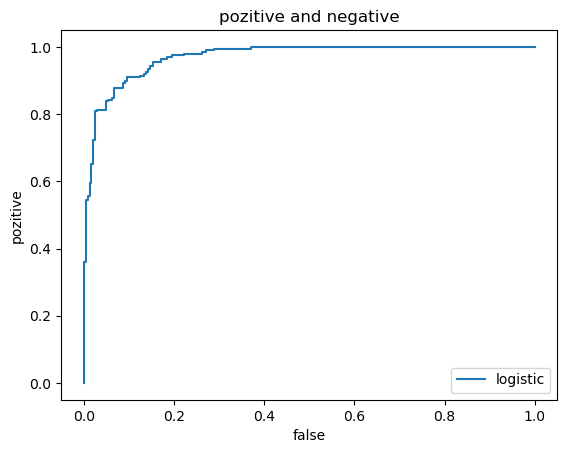

In [145]:
plt.plot(model_fpr,model_tpr,marker=',',label='logistic')
plt.xlabel('false')
plt.ylabel('pozitive')
plt.title('pozitive and negative')
plt.legend()
plt.show()

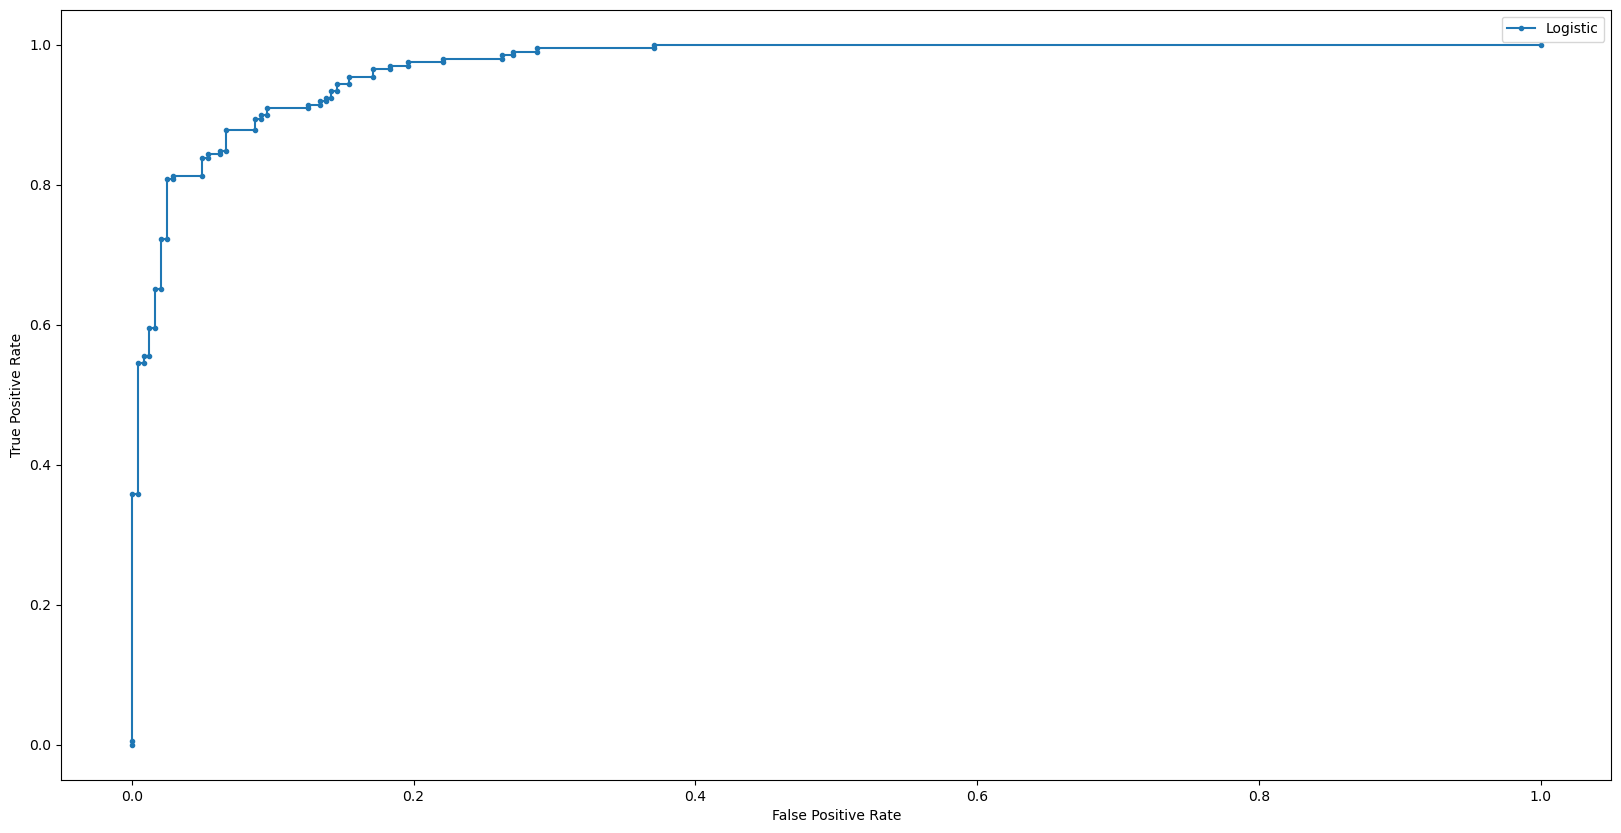

In [146]:
fig, ax = plt.subplots(figsize = (20,10))

ax.plot(model_fpr, model_tpr, marker = ".", label = "Logistic")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

Modelimizin başarılı tahmin oranı yüksek çünkü eğri sol üst köşeye dik bir şekilde yaklaşıyor.
Eğrinin altında kalan alan (AUC) yaklaşık 0.95 seviyesinde olduğu için sınıfları ayırt etme başarısı çok yüksektir.

SVC

SVC sectim SVR yerine cunku datam 0 ve 1 lerden oldutugu icin bu daha uygundu   

amacim 2 veriye ait bilgileri en iyi sekilde ayarlamak ve bunu yaparkende marji en uzak yere alabilmek 

In [147]:
from sklearn.svm import SVC

In [148]:
svc = SVC(kernel='linear')

In [149]:
svc.fit(X_train_scaler,y_train_c)

SVC(kernel='linear')

In [150]:
svc.coef_

array([[-8.48319336e-02,  5.82923219e-01, -2.48266669e-01,
        -2.57380448e-01,  0.00000000e+00, -3.87359931e-02,
         3.01182758e-01,  1.55573563e-01,  7.94031448e-01,
        -9.78785251e-02,  3.36614350e-01, -4.40468708e-01,
        -3.08202147e-01, -3.06675302e-01,  8.95841873e-01,
         3.77989472e-01,  2.52610286e-01, -1.53878577e-01,
        -1.95306024e-01,  1.15700788e-01, -1.08853052e-01,
        -2.23074375e-01, -3.33155659e-01,  1.25907471e+00,
         1.36910565e-01,  5.02564440e-02,  1.04997248e+00,
         1.19537105e-01,  1.59790131e-01,  6.22646315e-01,
         1.62515313e-01,  1.44684053e-01, -4.06973672e-01,
         7.24054752e-01,  4.15803137e-01, -2.54512143e-02,
        -3.56852921e-02, -2.75358165e-01,  5.39386003e-01,
         1.26364441e+00,  2.12217128e-02,  3.20654100e-01,
         1.62021537e-01,  3.29802358e-01,  3.02556702e-01,
         1.72833949e-01, -4.64135737e-02, -2.08939230e-01,
        -1.17019926e-01,  8.81408640e-02,  5.95323875e-0

coes kismini daha okunur bir sekilde yapmak isityorum

In [151]:
feature_imp = pd.Series(svc.coef_[0], index=X_train.columns).sort_values(ascending=False)
print(feature_imp)

RoofMatl_CompShg        2.573207
RoofMatl_Tar&Grv        1.971951
GarageCars              1.263644
1stFlrSF                1.259075
RoofMatl_WdShngl        1.102633
                          ...   
Foundation_PConc       -0.481272
Electrical_FuseF       -0.524297
Foundation_CBlock      -0.579111
Neighborhood_MeadowV   -0.767346
MSZoning_RM            -0.883088
Length: 183, dtype: float64


In [152]:
y_pred = svc.predict(X_test_scaler)

In [153]:
print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[199  41]
 [ 18 180]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       240
           1       0.81      0.91      0.86       198

    accuracy                           0.87       438
   macro avg       0.87      0.87      0.87       438
weighted avg       0.87      0.87      0.87       438



False pozitive 41 cikmis ve false negative 18 cikmistir verimizde vermizde toplamda 438 testin 379 nu dogru bir sekilde tahmin etmistir 

In [154]:
svc2 = SVC(kernel='poly')
svc2.fit(X_train_scaler,y_train_c)
y_pred = svc2.predict(X_test_scaler)
print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[219  21]
 [ 27 171]]
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       240
           1       0.89      0.86      0.88       198

    accuracy                           0.89       438
   macro avg       0.89      0.89      0.89       438
weighted avg       0.89      0.89      0.89       438



 Poly bizim icin False pozitive 21 ve False negative 27 cikmistir 438 testin 390 tanesini dogru sekilde tahmin etmistir 

In [155]:
svc2 = SVC(kernel='rbf')
svc2.fit(X_train_scaler,y_train_c)
y_pred = svc2.predict(X_test_scaler)
print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[215  25]
 [ 26 172]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       240
           1       0.87      0.87      0.87       198

    accuracy                           0.88       438
   macro avg       0.88      0.88      0.88       438
weighted avg       0.88      0.88      0.88       438



In [156]:
svc2 = SVC(kernel='sigmoid')
svc2.fit(X_train_scaler,y_train_c)
y_pred = svc2.predict(X_test_scaler)
print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[212  28]
 [ 17 181]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       240
           1       0.87      0.91      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



Hyperparameter Tuning

In [157]:
SVC()

SVC()

In [158]:
from sklearn.model_selection import GridSearchCV

In [159]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid', 'linear'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

In [160]:
grid = GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5)
grid.fit(X_train_scaler,y_train_c)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly', 'sigmoid', 'linear']})

In [161]:
grid.best_params_

{'C': 1, 'gamma': 'auto', 'kernel': 'sigmoid'}

In [162]:
grid.score

<bound method BaseSearchCV.score of GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly', 'sigmoid', 'linear']})>

In [163]:
y_pred = grid.predict(X_test_scaler)

In [164]:
print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[212  28]
 [ 18 180]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       240
           1       0.87      0.91      0.89       198

    accuracy                           0.89       438
   macro avg       0.89      0.90      0.89       438
weighted avg       0.90      0.89      0.90       438



GridSearchCV ile yapılan parametre optimizasyonu sonucunda model performansı belirgin şekilde artmıştır.
İlk durumdaki 59 toplam hata  en iyi parametre kombinasyonuyla 28 False Positive, 18 False Negative düşürülmüş ve genel doğruluk oranı (accuracy) %90 seviyesine yükseltilmiştir.

NAIVE BAYES 

In [165]:
from sklearn.naive_bayes import GaussianNB

In [166]:
gnb = GaussianNB()

In [167]:
gnb.fit(X_train_scaler,y_train_c)

GaussianNB()

In [168]:
y_pred = gnb.predict(X_test_scaler)

In [169]:
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))
print(accuracy_score(y_test_c,y_pred))

[[ 94 146]
 [  8 190]]
              precision    recall  f1-score   support

           0       0.92      0.39      0.55       240
           1       0.57      0.96      0.71       198

    accuracy                           0.65       438
   macro avg       0.74      0.68      0.63       438
weighted avg       0.76      0.65      0.62       438

0.6484018264840182


Naive Bayes değişkenlerin birbirinden bağımsız olduğunu varsayar ev fiyatı veri setindeki değişkenler (m² ve oda sayısı gibi) birbiriyle yüksek ilişkili olduğu için model bu varsayımı karşılayamamış ve %65 doğruluk oranında kalmıştır bu durum  verimize Logistic Regression ve SVC gibi modellerin çok daha uygun olduğunu göstermektedir.

KNN

In [170]:
from sklearn.neighbors import KNeighborsClassifier

In [171]:
classfier = KNeighborsClassifier(n_neighbors=5,algorithm="auto",weights="uniform")

In [172]:
classfier.fit(X_train_scaler,y_train_c)

KNeighborsClassifier()

In [173]:
y_pred = classfier.predict(X_test_scaler)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "C:\Users\PC\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\encodings\cp1254.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9e in position 26: character maps to <undefined>
C:\Users\PC\anaconda3\Lib\site-package

In [174]:
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))
print(accuracy_score(y_test_c,y_pred))

[[210  30]
 [ 28 170]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       240
           1       0.85      0.86      0.85       198

    accuracy                           0.87       438
   macro avg       0.87      0.87      0.87       438
weighted avg       0.87      0.87      0.87       438

0.867579908675799


In [175]:
classfier = KNeighborsClassifier(n_neighbors=5,algorithm="kd_tree",weights="uniform")
classfier.fit(X_train_scaler,y_train_c)
classfier.predict(X_test_scaler)
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))
print(accuracy_score(y_test_c,y_pred))

[[210  30]
 [ 28 170]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       240
           1       0.85      0.86      0.85       198

    accuracy                           0.87       438
   macro avg       0.87      0.87      0.87       438
weighted avg       0.87      0.87      0.87       438

0.867579908675799


kd_tree ile auto arasinda cok bir fark yok sadece calisma hizlari farklidir 

DECISION TREE 

In [176]:
from sklearn.tree import DecisionTreeClassifier

In [177]:
tree = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=15)

In [178]:
tree.fit(X_train_scaler,y_train_c)

DecisionTreeClassifier(max_depth=3, random_state=15)

In [179]:
y_pred = tree.predict(X_test_scaler)

In [180]:
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))
print(accuracy_score(y_test_c,y_pred))

[[185  55]
 [ 14 184]]
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       240
           1       0.77      0.93      0.84       198

    accuracy                           0.84       438
   macro avg       0.85      0.85      0.84       438
weighted avg       0.86      0.84      0.84       438

0.8424657534246576


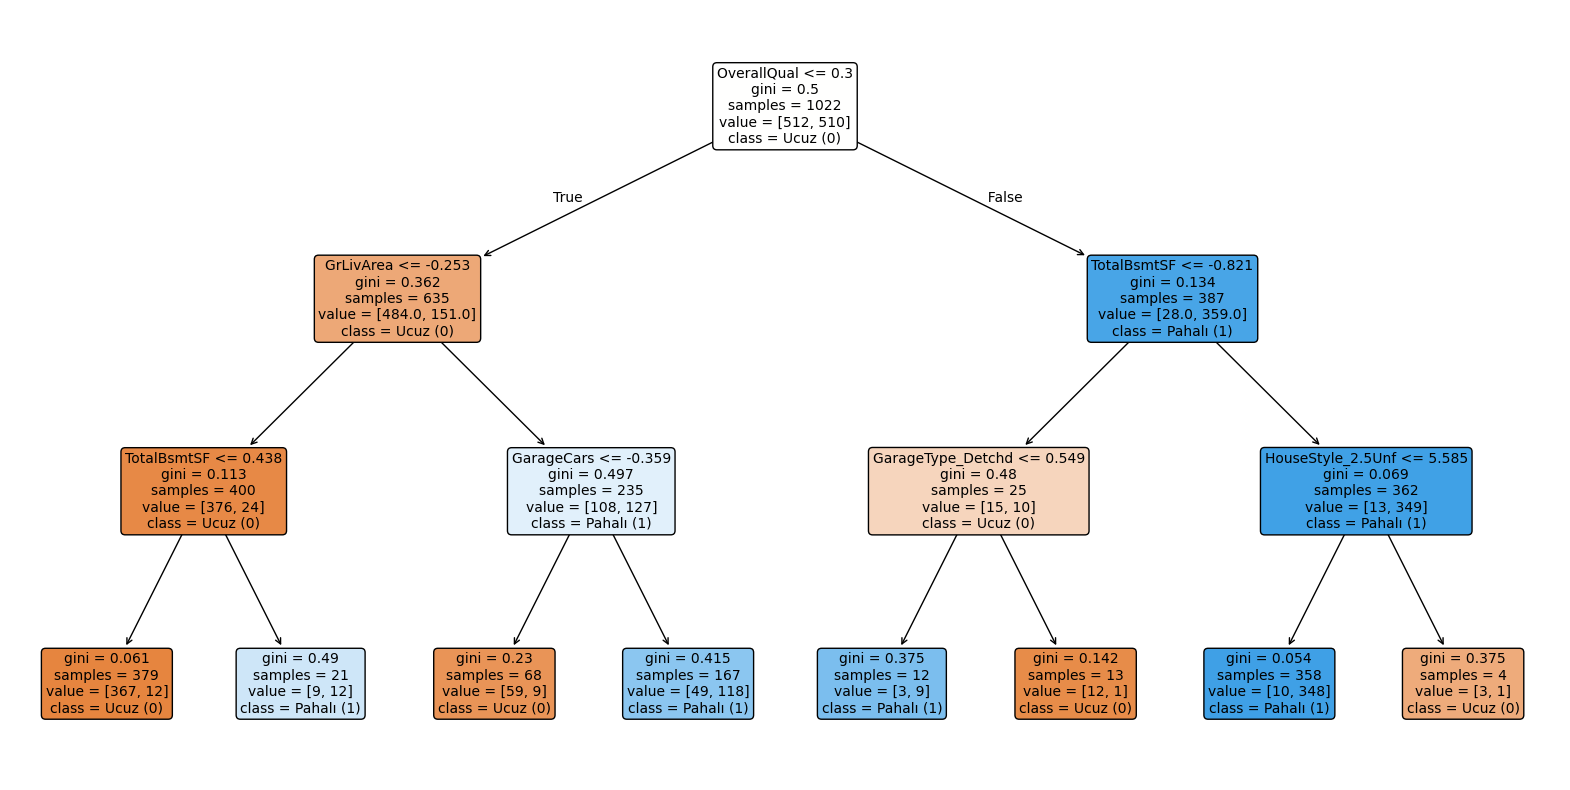

In [181]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree, 
          filled=True,             # Kutuları çoğunluk sınıfına göre renklendirir
          feature_names=X_train.columns,  # Hangi özellikten böldüğünü yazması için sütun isimleri
          class_names=['Ucuz (0)', 'Pahalı (1)'], # 0 ve 1 sınıflarının isimleri
          rounded=True,            # Kutuların köşelerini yuvarlak yapar
          fontsize=10)             # Yazı boyutu

plt.show()

HYPERPAREMETER TUNING 

In [182]:
param = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best'],  # 'random' kaldırıldı, deterministik ve en iyi ayrımları yapacak
    'max_depth': [3, 4, 5, 6, 7, 8],
    'max_features': [None, 'sqrt']
}

In [183]:
from sklearn.model_selection import GridSearchCV

In [184]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(random_state=15), param_grid=param, cv=5, scoring='accuracy', n_jobs=-1)

In [185]:
grid.fit(X_train_scaler,y_train_c)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=15), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'max_features': [None, 'sqrt'], 'splitter': ['best']},
             scoring='accuracy')

In [186]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'splitter': 'best'}

In [187]:
grid.scoring

'accuracy'

In [188]:
y_pred = grid.predict(X_test_scaler)

In [189]:
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))
print(accuracy_score(y_test_c,y_pred))

[[195  45]
 [ 15 183]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       240
           1       0.80      0.92      0.86       198

    accuracy                           0.86       438
   macro avg       0.87      0.87      0.86       438
weighted avg       0.87      0.86      0.86       438

0.863013698630137


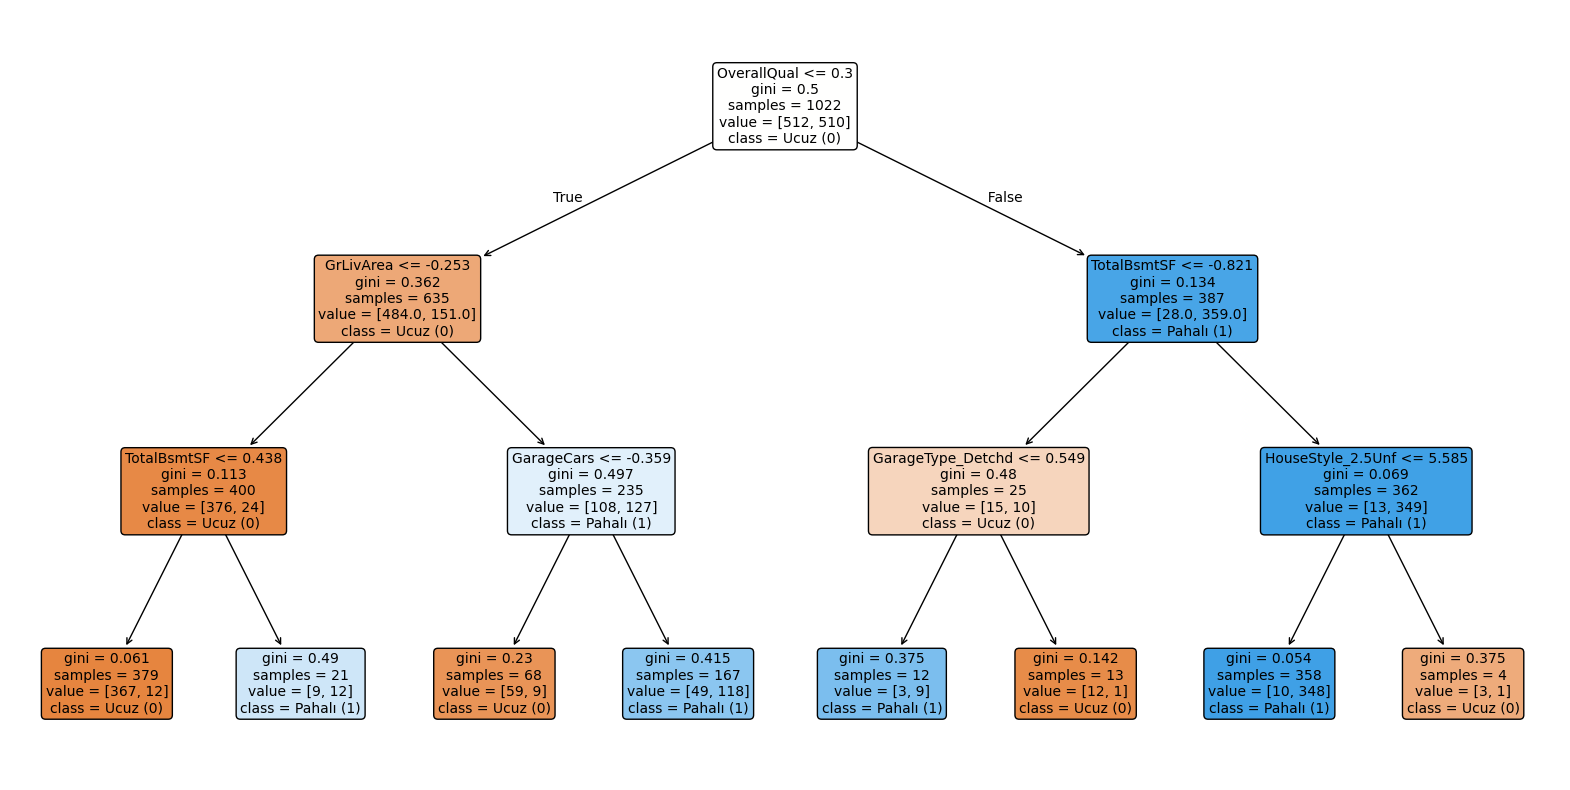

In [190]:
plt.figure(figsize=(20, 10))

plot_tree(tree, 
          filled=True, 
          feature_names=X_train.columns, 
          class_names=['Ucuz (0)', 'Pahalı (1)'], 
          rounded=True, 
          fontsize=10)

plt.show()

ENSEBLE YONTEMELRI

Bu bölümde tek bir sınıflandırma modeli yerine, birden fazla zayıf veya bağımsız modelin (öğrenicinin) tahminlerini bir araya getirerek (oylama veya ardışık iyileştirme ile) daha güçlü ve kararlı bir nihai tahmin elde etmeyi hedefliyoruz.

In [191]:
from sklearn.ensemble import RandomForestClassifier

In [192]:
rfc = RandomForestClassifier(n_estimators=10,random_state=15)
rfc.fit(X_train_scaler,y_train_c)

RandomForestClassifier(n_estimators=10, random_state=15)

In [193]:
y_pred = rfc.predict(X_test_scaler)

In [195]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.8926940639269406
[[221  19]
 [ 28 170]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       240
           1       0.90      0.86      0.88       198

    accuracy                           0.89       438
   macro avg       0.89      0.89      0.89       438
weighted avg       0.89      0.89      0.89       438



In [197]:
rfc = RandomForestClassifier(n_estimators=1000,random_state=15)
rfc.fit(X_train_scaler,y_train_c)
y_pred = rfc.predict(X_test_scaler)
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.906392694063927
[[222  18]
 [ 23 175]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       240
           1       0.91      0.88      0.90       198

    accuracy                           0.91       438
   macro avg       0.91      0.90      0.91       438
weighted avg       0.91      0.91      0.91       438



In [198]:
rfc.feature_importances_

array([8.33883929e-03, 1.15004798e-02, 1.32757825e-02, 2.39265630e-02,
       0.00000000e+00, 1.42142840e-03, 6.26613753e-02, 7.00559986e-03,
       5.64689577e-02, 2.37510404e-02, 9.59673501e-03, 3.42442831e-02,
       1.38960960e-03, 3.63846588e-02, 2.08178460e-03, 4.50697948e-03,
       9.38845139e-03, 1.31644716e-02, 2.28736922e-03, 2.75918089e-03,
       1.06026834e-02, 3.71410821e-02, 9.13850108e-03, 3.71818424e-02,
       2.40689347e-02, 5.28858196e-04, 8.15402203e-02, 2.57792655e-03,
       1.28171403e-03, 6.42932638e-02, 1.06166215e-02, 5.50296250e-03,
       2.05380542e-03, 3.79492553e-02, 1.85423108e-02, 1.70098460e-03,
       2.63862453e-02, 3.99276349e-02, 2.49010890e-02, 4.40113164e-02,
       1.80174670e-03, 9.61825972e-03, 1.94914633e-02, 2.62389274e-03,
       8.06701397e-04, 4.06184043e-03, 4.36847611e-04, 6.33623718e-04,
       6.50204401e-03, 4.05955007e-03, 8.94307787e-04, 2.57352924e-04,
       4.08775489e-03, 1.00766456e-02, 9.35768011e-05, 4.12950728e-04,
      

feature importance hangi satira ne kadar guvendigimizi gosteren kodmuzdur 

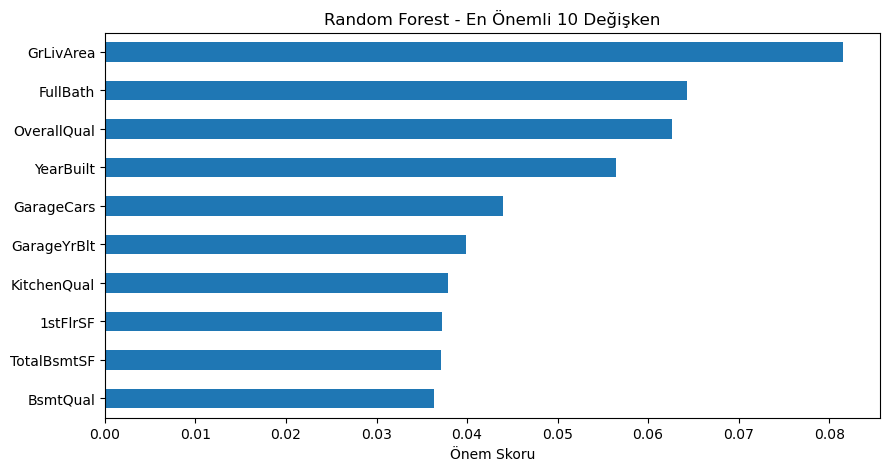

In [199]:
importances = pd.Series(rfc.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 5))
importances.nlargest(10).plot(kind='barh')
plt.title('Random Forest - En Önemli 10 Değişken')
plt.xlabel('Önem Skoru')
plt.gca().invert_yaxis()
plt.show()

ADABOOST

hatalardan ders cikartarak zayif halkalari guclendirmeye calisacaz simdi 

In [201]:
from sklearn.ensemble import AdaBoostClassifier

In [204]:
ads = AdaBoostClassifier()
ads.fit(X_train_scaler,y_train_c)
y_pred = ads.predict(X_test_scaler)
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.91324200913242
[[216  24]
 [ 14 184]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       240
           1       0.88      0.93      0.91       198

    accuracy                           0.91       438
   macro avg       0.91      0.91      0.91       438
weighted avg       0.91      0.91      0.91       438



HYPERPARAMETER TUNING 

In [206]:
adabost_param = {
    'n_estimators':[50,70,120,150,200],
    'learning_rate': [0.001,0.01,0.1,1,10]
}

In [207]:
grid = GridSearchCV(estimator=AdaBoostClassifier(),param_grid=adabost_param,cv=3,verbose=1,n_jobs=-1)

In [208]:
grid.fit(X_train_scaler,y_train_c)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 120, 150, 200]},
             verbose=1)

In [209]:
grid.best_params_

{'learning_rate': 0.1, 'n_estimators': 200}

In [210]:
grid.best_score_

np.float64(0.9207463630613536)

In [217]:
ads = AdaBoostClassifier(learning_rate=1,n_estimators=200)

In [218]:
ads.fit(X_train_scaler,y_train_c)
y_pred = ads.predict(X_test_scaler)

In [219]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.9178082191780822
[[218  22]
 [ 14 184]]
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       240
           1       0.89      0.93      0.91       198

    accuracy                           0.92       438
   macro avg       0.92      0.92      0.92       438
weighted avg       0.92      0.92      0.92       438



GRADIENT BOOSTING 

her agaci kendinde onceki agacin hatasina odaklaanarak olusturur 

In [221]:
from sklearn.ensemble import GradientBoostingClassifier

In [222]:
grad = GradientBoostingClassifier(n_estimators=100,max_depth=3,learning_rate=0.1)

In [223]:
grad.fit(X_train_scaler,y_train_c)

GradientBoostingClassifier()

In [224]:
y_pred = grad.predict(X_test_scaler)

In [225]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.9018264840182648
[[214  26]
 [ 17 181]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       240
           1       0.87      0.91      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



HYPERPARAMETER TUNING 

In [232]:
params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'loss': ['log_loss', 'exponential'], # Sınıflandırma için geçerli kayıp fonksiyonları
    'learning_rate': [0.01, 0.1, 0.5]
}

In [233]:
random_grad = RandomizedSearchCV(estimator=GradientBoostingClassifier(),param_distributions=params,cv=5)

In [234]:
random_grad.fit(X_train_scaler,y_train_c)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})

In [235]:
random_grad.best_params_

{'n_estimators': 100,
 'max_depth': 3,
 'loss': 'exponential',
 'learning_rate': 0.5}

In [236]:
random_grad.score

<bound method BaseSearchCV.score of RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})>

In [238]:
grad = GradientBoostingClassifier(n_estimators=100,max_depth=3,loss='exponential',learning_rate=0.5)

In [239]:
grad.fit(X_train_scaler,y_train_c)

GradientBoostingClassifier(learning_rate=0.5, loss='exponential')

In [242]:
y_pred = grad.predict(X_test_scaler)

In [243]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.9018264840182648
[[215  25]
 [ 18 180]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       240
           1       0.88      0.91      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



XGBOOST 

Gradient Boosting mantığını düzenlileştirme (L1/L2) ve sistem optimizasyonlarıyla geliştirerek ezberlemeyi engelleyen ve daha hızlı çalışan gelişmiş bir boosting algoritmasıdır

In [245]:
from xgboost import XGBClassifier

In [247]:
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train_scaler,y_train_c)
y_pred = xgb.predict(X_test_scaler)
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.9041095890410958
[[215  25]
 [ 17 181]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       240
           1       0.88      0.91      0.90       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



HYPERPARAMETER TUNING 

In [249]:
params = {
    'n_estimators':[100,200,300,500],
    'learning_rate':[0.01,0.1],
    'max_depth':[5,8,12,20,30],
    'colsample_bytree':[0.3,0.4,0.5,0.8,1]
}

In [255]:
grid = GridSearchCV(estimator=XGBClassifier(),param_grid=params,cv=5,n_jobs=-1)

In [256]:
grid.fit(X_train_scaler,y_train_c)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.1],
                         'max_depth': [5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300, 500]})

In [257]:
grid.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 8,
 'n_estimators': 100}

In [258]:
grid.best_score_

np.float64(0.940286944045911)

In [261]:
xgb = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=8,colsample_bytree=0.8)

In [262]:
xgb.fit(X_train_scaler,y_train_c)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [263]:
y_pred = xgb.predict(X_test_scaler)

In [264]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.9018264840182648
[[216  24]
 [ 19 179]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       240
           1       0.88      0.90      0.89       198

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



LIGHTGBM 

Ağaçları seviye bazlı büyütmek yerine yaprak bazlI büyüterek çok daha hızlı eğitilen, büyük verilerde yüksek performans ve düşük bellek kullanımı sağlayan gelişmiş bir boosting algoritmasıdır

In [267]:
import lightgbm as lgb

In [269]:
clf = lgb.LGBMClassifier(verbosity=1,n_jobs=-1)
clf.fit(X_train_scaler,y_train_c)

[LightGBM] [Info] Number of positive: 510, number of negative: 512
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3054
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499022 -> initscore=-0.003914
[LightGBM] [Info] Start training from score -0.003914
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(n_jobs=-1, verbosity=1)

In [270]:
y_pred =clf.predict(X_test_scaler)

In [271]:
print(accuracy_score(y_test_c,y_pred))
print(confusion_matrix(y_test_c,y_pred))
print(classification_report(y_test_c,y_pred))

0.908675799086758
[[215  25]
 [ 15 183]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       240
           1       0.88      0.92      0.90       198

    accuracy                           0.91       438
   macro avg       0.91      0.91      0.91       438
weighted avg       0.91      0.91      0.91       438



In [273]:
clf.feature_importances_

array([175,  38,  98, 228,   0,   1,  78,  38, 171,  93,  87,  13,   0,
        15,   6,  34,  40, 101,   1,   7,  94, 212,  25, 142,  80,   0,
       278,   4,   3,  45,  13,  23,  10,  43,  18,   1,  36,  86,  44,
        60,   0,  71,  73,  10,   0,  27,   0,   4,  42,  31,   3,   0,
         6,  35,   0,   0,   0,  18,   0,   0,   4,   1,   1,   0,  12,
         0,   0,   1,   0,   0,  17,  15,   1,   0,   0,   0,  20,   0,
         2,   0,   1,   2,   0,   0,   1,   0,  11,   0,   1,   9,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   3,   1,   0,   2,   0,   0,   6,   0,   4,   5,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   9,   0,   0,
         6,   0,   1,   2,   0,   0,   8,   5,   0,   0,   0,   0,   0,
         0,   1,   0,   0,   5,   5,   5,   5,   4,  14,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   0,   0,   0,   1,   9,   0,   0,
         0,   8,   0,   0,   0,   0,   0,   1,   0,   5,   0,   

In [277]:
importances = clf.feature_importances_

In [278]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [279]:
print(feature_importance.head(15))

         Feature  Importance
26     GrLivArea         278
3        LotArea         228
21   TotalBsmtSF         212
0             Id         175
8      YearBuilt         171
23      1stFlrSF         142
17    BsmtFinSF1         101
2    LotFrontage          98
20     BsmtUnfSF          94
9   YearRemodAdd          93
10    MasVnrArea          87
37   GarageYrBlt          86
24      2ndFlrSF          80
6    OverallQual          78
42   OpenPorchSF          73


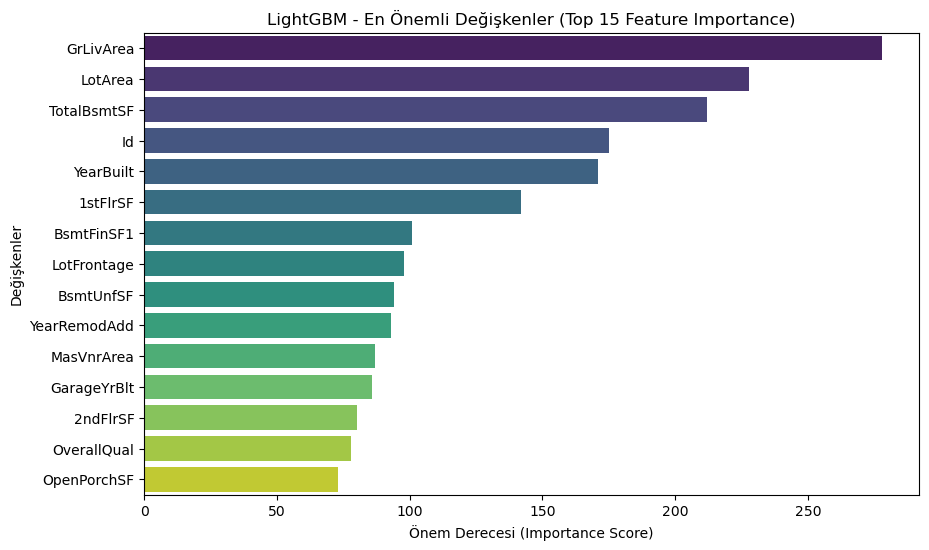

In [281]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15),
    hue='Feature',      # Uyarıyı çözen ekleme
    palette='viridis',
    legend=False        # Lejantı gizleme
)
plt.title('LightGBM - En Önemli Değişkenler (Top 15 Feature Importance)')
plt.xlabel('Önem Derecesi (Importance Score)')
plt.ylabel('Değişkenler')
plt.show()

### 📊 Model Performans Değerlendirmesi ve Genel Sonuç

* **En Başarılı Model:** Hiperparametre optimizasyonu yapılan **AdaBoost Classifier (%91.78 Accuracy)**, test seti üzerinde en yüksek doğruluk ve F1-score değerine ulaşmıştır.
* **Algoritma Karşılaştırması:** Tekil karar ağacı (`DecisionTree ~%84`) zayıf kalırken; **Random Forest (%90.63)**, **LightGBM (%90.86)**, **Gradient Boosting (%90.18)** ve **XGBoost (%90.18)** modelleri %90 barajını aşarak kararlı performans sergilemiştir.
* **Öznitelik Önemi (Feature Importance):** LightGBM model analizi; ev fiyatını sınıflandırmada en belirleyici faktörlerin **GrLivArea (Yaşam Alanı Metrekaresi)**, **LotArea (Arsa Alanı)**, **TotalBsmtSF (Bodrum Alanı)** ve **YearBuilt (Yapım Yılı)** olduğunu göstermiştir.
* **Özet:** Ardışık öğrenme ve hata düzeltme mantığıyla çalışan boosting algoritmaları, gayrimenkul fiyat sınıflandırmasında en yüksek genelleştirme yeteneğini elde etmiştir.